# Multi-Video Comparison: Stacked Detections per Region

This notebook loads the filtered in-ROI, persistence-filtered detection CSVs from the four per-video analysis notebooks and plots them with a shared time axis.

Features:
- Common x-axis (seconds since start of each video).
- Uniform y-axis limit across all panels (max count observed).
- One subplot per video, stacked vertically, sharing the x-axis.
- Per-region line plots (excluding 'outside').
- Moonrise vertical line specific to each video (offset from video start).

Adjust configuration in the first code cell if needed (e.g., bin size, moonrise offsets, start clocks).

In [11]:
# Configuration: list of videos and their moonrise offsets (H:MM or HH:MM)
# Video stems MUST match the processed filtered CSV naming pattern: <stem>_streaks_in_roi_filtered.csv
videos = [
    'GX010063_2025Nov10',
    'GX010067_2025Nov12',
    'GX010072_2025Nov13',
    'GX01007X_2025Nov14'
]

# Moonrise offsets extracted from individual notebooks (seconds after start clock).
# If a value is unknown or needs update, edit below.
moonrise_offsets = {
    'GX010063_2025Nov10': '4:30',
    'GX010067_2025Nov12': '5:24',
    'GX010072_2025Nov13': '6:14',
    'GX01007X_2025Nov14': '7:01',
}

# Optional: start clock labels per video (for legend or title context). If not needed, can leave identical.
start_clocks = {
    'GX010063_2025Nov10': '19:00',
    'GX010067_2025Nov12': '19:00',
    'GX010072_2025Nov13': '19:00',
    'GX01007X_2025Nov14': '19:00',
}

# Time bin size (seconds) for aggregation. Match per-video notebooks (1 and 60 used there). Choose one here.
BIN_SECONDS = 60.0

# Path setup
from pathlib import Path
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Videos:', videos)
print('Moonrise offsets:', moonrise_offsets)
print('Bin size (s):', BIN_SECONDS)

Videos: ['GX010063_2025Nov10', 'GX010067_2025Nov12', 'GX010072_2025Nov13', 'GX01007X_2025Nov14']
Moonrise offsets: {'GX010063_2025Nov10': '4:30', 'GX010067_2025Nov12': '5:24', 'GX010072_2025Nov13': '6:14', 'GX01007X_2025Nov14': '7:01'}
Bin size (s): 60.0


In [12]:
# Utility functions
import math, json, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker

def parse_moonrise_offset(s: str) -> int:
    parts = s.strip().split(':')
    if len(parts) < 2: raise ValueError(f'Invalid moonrise offset: {s}')
    h = int(parts[0]); m = int(parts[1]); return h*3600 + m*60

def hhmm_formatter_factory():
    def _fmt(x, pos):
        total_seconds = float(x)
        hours = int((total_seconds // 3600) % 24)
        minutes = int((total_seconds % 3600) // 60)
        return f'{hours:02d}:{minutes:02d}'
    return _fmt

def load_filtered_counts(stem: str, bin_seconds: float) -> pd.DataFrame:
    csv_path = PROCESSED_DIR / f'{stem}_streaks_in_roi_filtered.csv'
    if not csv_path.exists():
        # Fallback to raw if filtered missing
        raw = PROCESSED_DIR / f'{stem}_streaks.csv'
        if not raw.exists():
            raise FileNotFoundError(f'Neither filtered nor raw CSV found for video stem {stem}')
        with open(raw, 'r') as f:
            lines = f.readlines()
        header_idx = next((i for i,l in enumerate(lines[:100]) if l.lower().startswith('frame,')), 0)
        df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
        print(f'[WARN] Using RAW CSV (not filtered) for {stem}')
    else:
        with open(csv_path, 'r') as f:
            lines = f.readlines()
        header_idx = next((i for i,l in enumerate(lines[:100]) if l.lower().startswith('frame,')), 0)
        df = pd.read_csv(io.StringIO(''.join(lines[header_idx:])))
    if 'region' not in df.columns:
        raise ValueError(f'CSV for {stem} missing region column')
    # Exclude outside
    dfi = df[df['region'] != 'outside'].copy()
    if dfi.empty:
        return pd.DataFrame(columns=['time_bin'])
    dfi['time_bin'] = (dfi['time_s'] // bin_seconds) * bin_seconds
    counts = dfi.groupby(['region','time_bin']).size().reset_index(name='count')
    pivot = counts.pivot(index='time_bin', columns='region', values='count').fillna(0)
    # Ensure contiguous bins from min to max
    start_bin = float(pivot.index.min()) if len(pivot.index) else 0.0
    end_bin = float(pivot.index.max()) if len(pivot.index) else 0.0
    all_bins = np.arange(start_bin, end_bin + bin_seconds, bin_seconds, dtype=float)
    pivot = pivot.reindex(all_bins, fill_value=0)
    pivot.index.name = 'time_bin'
    return pivot

# Load all counts and accumulate global y max and region set
all_counts = {}  # stem -> pivot DataFrame
all_regions = set()
global_ymax = 0
for stem in videos:
    pivot = load_filtered_counts(stem, BIN_SECONDS)
    all_counts[stem] = pivot
    all_regions.update(pivot.columns.tolist())
    if not pivot.empty:
        local_max = pivot.max().max()
        global_ymax = max(global_ymax, local_max)
    print(f'Loaded {stem}: shape={pivot.shape}, local_max={pivot.max().max() if not pivot.empty else 0}')

print('All regions union:', sorted(all_regions))
print('Global y-axis max:', global_ymax)

Loaded GX010063_2025Nov10: shape=(161, 3), local_max=54.0
Loaded GX010067_2025Nov12: shape=(711, 3), local_max=22.0
Loaded GX010072_2025Nov13: shape=(719, 3), local_max=13.0
Loaded GX01007X_2025Nov14: shape=(710, 2), local_max=27.0
All regions union: ['left', 'middle', 'right', 'roi_1', 'roi_2']
Global y-axis max: 54.0


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

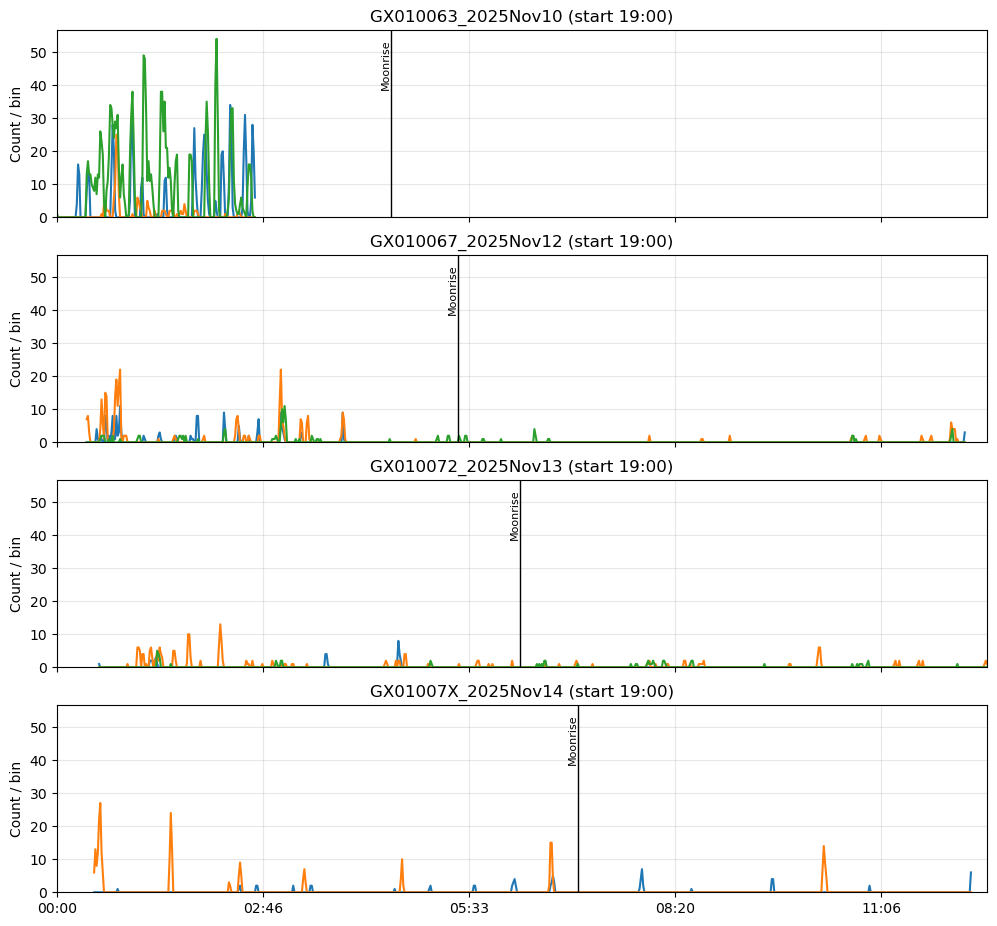

In [13]:
# Plot stacked panels
if not all_counts:
    raise RuntimeError('No data loaded to plot.')

fig, axes = plt.subplots(len(videos), 1, figsize=(12, 2.8*len(videos)), sharex=True)
if len(videos) == 1: axes = [axes]  # ensure iterable

moonrise_seconds = {stem: parse_moonrise_offset(moonrise_offsets.get(stem, '0:00')) for stem in videos}

# Common x-range: union of all time bins (since each starts at 0 should be fine).
# If different durations, extend to max end.
max_end = 0.0
for stem, pivot in all_counts.items():
    if not pivot.empty:
        max_end = max(max_end, float(pivot.index.max()))

fmt = mticker.FuncFormatter(hhmm_formatter_factory())

for ax, stem in zip(axes, videos):
    pivot = all_counts[stem]
    if pivot.empty:
        ax.text(0.5, 0.5, f'No in-ROI detections for {stem}', ha='center', va='center')
        ax.set_ylim(0, 1)
    else:
        # Plot each region present in this pivot
        for region in pivot.columns:
            ax.plot(pivot.index.values, pivot[region].values, label=region)
        ax.set_ylim(0, global_ymax * 1.05 if global_ymax > 0 else 1)
        # Moonrise line
        mr = moonrise_seconds.get(stem, 0)
        if 0 <= mr <= max_end:
            ax.axvline(mr, color='k', linestyle='-', linewidth=1.0)
            ax.text(mr, ax.get_ylim()[1]*0.95, 'Moonrise', rotation=90, va='top', ha='right', fontsize=8, color='k')
    ax.grid(alpha=0.3)
    clock_label = start_clocks.get(stem, '')
    ax.set_title(f'{stem} (start {clock_label})')
    ax.set_ylabel('Count / bin')
    ax.xaxis.set_major_formatter(fmt)
    # Optional: light x-limit padding
    ax.set_xlim(0, max_end)

# Put legend only on the first axis to avoid clutter (or last axis)
if axes:
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(loc='upper left', ncol=2, fontsize=8, frameon=False)

axes[-1].set_xlabel('Clock Time (HH:MM from start)')
plt.tight_layout()
out_path = FIGURES_DIR / f'multi_video_comparison_bins_{int(BIN_SECONDS)}s.png'
plt.savefig(out_path, dpi=200)
print('Saved stacked comparison figure to', out_path)
plt.show()